# Report on MPW3 – Image Captioning (IC)
<div class="alert alert-block alert-warning">
This is a <b>report NB</b> for submission together with PDF file. Original <code>captioning_starter.ipynb</code> file was used as a template, but many markdown cells are shorten or removed for easier navigation.
</div>


# Image Captioning on the Flicker8k Dataset


##  Team Name and Members
* Team Name: **demidova_keller** (used in submitted file names)
* Student 1: Iuliia Demidova (iuliia.demidova@students.fhnw.ch)
* Student 2: Lucas Keller (lucas.keller@students.fhnw.ch)


## 1. Project Setup


### 1.1 Create the virtual environment

In [1]:
# imports
import sys
from pathlib import Path
# fixing imports for provided_sources/ modules
sys.path.append(str(Path().resolve().parents[1])) 
# I had to add this section above for importing the provided_sources modules (Lucas)

# stdlib
import copy
import json
import math
import random
import textwrap
import time
from collections import defaultdict
from dataclasses import asdict, is_dataclass
from pathlib import Path
from typing import Any

# third-party
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision
import wandb
from nltk.translate.bleu_score import SmoothingFunction, corpus_bleu
from PIL import Image
from torchvision import transforms
from torchvision.models import ResNet18_Weights, resnet18
from tqdm.auto import tqdm

# local project imports
import ic_configs
from dataloader import build_tokenizer_from_split, create_caption_dataloader
from tokenizer import tokenize
from notebooks.ic.ic_utils import (
    _filter_wandb_metrics,
    _is_better,
    _wandb_safe,
    build_references_by_image_id,
    collect_fixed_eval_subset,
    decode_token_ids,
    evaluate_bleu,
    evaluate_loss,
    generate_batch_token_ids,
    seed_everything,
    train_one_epoch,
)

print("torch version:", torch.__version__)
print("torchvision version:", torchvision.__version__)

# imports
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torchvision

from dataloader import (
    build_tokenizer_from_split,
    create_caption_dataloader
)

from tokenizer import tokenize

import textwrap
import random
import math
import numpy as np
from collections import defaultdict
from typing import Any
import torch
import torch.nn as nn
from torchvision import transforms
from nltk.translate.bleu_score import SmoothingFunction, corpus_bleu
from tqdm.auto import tqdm
import time
from pathlib import Path
import ic_configs
import copy
from notebooks.ic.ic_utils import seed_everything, train_one_epoch, evaluate_loss, evaluate_bleu, \
    build_references_by_image_id, collect_fixed_eval_subset, _wandb_safe, _is_better, _filter_wandb_metrics, \
    generate_batch_token_ids, decode_token_ids
from torchvision.models import resnet18, ResNet18_Weights

import copy
import json
from dataclasses import asdict, is_dataclass
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import wandb

torch version: 2.10.0+cu128
torchvision version: 0.25.0+cu128


### 1.2 Download the dataset
* The Flickr8k dataset used in this challenge is available under [Flickr 8k Dataset - Kaggle](https://www.kaggle.com/datasets/adityajn105/flickr8k).
* Captions, splits, and images are included in the `../notebooks/data/` directory. The data directory has this structure:

<img src="data_structure.png"/>

## 2. Data loader and Tokenizer

### 2.1 Data loader
The repository includes:
 * `Dataset`-class: `Flickr8kCaptionsDatasetBase`
  * `DataLoader`'s

that are based on this specific structure of the data directory.

You can use `create_caption_dataloader` for obtaining instances for the train and test data loaders.

### 2.2 Tokenizer
You can configure it with the `tokenizer` provided in the repo.

The `tokenizer` performs some **preprocessing** steps of the captions. It also **creates a vocabulary** from the training data and then provides **a mapping from the words to tokens**.

Note that there are also some special tokens introduced that are important when processing the captions during training or generating the captions during inference:

| Word    | ID | Role                                                                                                           |
|---------|----|----------------------------------------------------------------------------------------------------------------|
| `<pad>` | 0  | **padding** for filling up sequence to a given length in a mini-batch.                                         |
| `<bos>` | 1  | **beginning of sentence** - each tokenized sentence should start with `<bos>`, i.e. also the generated ones.   |
| `<eos>` | 2  | **end of sentence** - for fixed length captions will signal that the rest will consist of `<pad>`-tokens only. |
| `<unk>` | 3  | **unknown - not available in vocabulary**                                                                      |

### 2.3 Data preprocessing and Augmentation
> See `MPW-03 > 6 Training Requirements > Data augmentation`

Data augmentation was added to transforms of train subset.
* Transforms used for **preprocessing and augmenting the images** and are passed to the `create_caption_dataloader`-method.
* The mini-batches created by the dataloader have the following structure:
    * `(images, captions, lengths, image_ids, raw_captions)`.


* **Captions are built from the training vocabulary only**, and `lengths` may let you mask padding tokens in the loss.


In [2]:
# Transforms
IMAGENET_SIZE = 224
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

def _convert_to_rgb(image: Image.Image) -> Image.Image:
    return image.convert("RGB")

def build_train_transforms(augmentation= "medium") -> transforms.Compose:
    """choos the strength of the augmentation:
    - none: only resize and normalize.
    - light: resize, random crop, horizointal flip.
    - medium: random rotation, random resizecrop, random horizontal flip, color jitter.
    """
    if augmentation == "none":
        return transforms.Compose([
            transforms.Lambda(_convert_to_rgb),
            transforms.Resize((IMAGENET_SIZE, IMAGENET_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])

    if augmentation == "light":
        return transforms.Compose([
            transforms.Lambda(_convert_to_rgb),
            transforms.Resize((256, 256)),
            transforms.RandomCrop((IMAGENET_SIZE, IMAGENET_SIZE)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])

    if augmentation == "medium":
        return transforms.Compose([
            transforms.Lambda(_convert_to_rgb),
            transforms.RandomApply([
                transforms.RandomRotation(degrees=3),
            ], p=0.25),
            transforms.RandomResizedCrop(
                size=IMAGENET_SIZE,
                scale=(0.85, 1.0),
                ratio=(0.9, 1.1),
            ),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ColorJitter(
                brightness=0.15,
                contrast=0.15,
                saturation=0.10,
                hue=0.02,
            ),
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])

    raise ValueError(f"Unknown augmentation: {augmentation}")

def build_test_transforms() -> transforms.Compose:
    return transforms.Compose([
            transforms.Lambda(_convert_to_rgb),
            transforms.Resize((IMAGENET_SIZE,IMAGENET_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)])

def denormalize_image(image: torch.Tensor) -> torch.Tensor:
    """Undo ImageNet normalization for visualization."""
    mean_tensor = image.new_tensor(IMAGENET_MEAN).view(-1, 1, 1)
    std_tensor = image.new_tensor(IMAGENET_STD).view(-1, 1, 1)
    return (image * std_tensor + mean_tensor).clamp(0, 1)

In [3]:
# data dir in the same dir as NB
data_dir = "data/"
# Tokenizer / dataloader parameters
# Given dataset is relatively small, so we:
#   filter out rare words to reduce vocabulary noise,
#   keep captions long enough to avoid cutting normal sentences,
#   and use a batch size that is okay for CPU/MPS

MIN_WORD_FREQ = 5   # Keep words appearing at least 5 times in train captions
MAX_LEN = 40        # Max caption length including <bos>/<eos>, longer captions are cut
BATCH_SIZE = 32     # Kind of default value

In [4]:
# Vocabulary is built ONLY from training captions to avoid test leakage.
tokenizer = build_tokenizer_from_split(
    split="train",
    data_dir=data_dir,
    min_freq=MIN_WORD_FREQ,
)

# To test the provided tokenizer:
assert tokenizer.stoi["<pad>"] == 0
assert tokenizer.stoi["<bos>"] == 1
assert tokenizer.stoi["<eos>"] == 2
assert tokenizer.stoi["<unk>"] == 3

PAD_IDX = tokenizer.stoi["<pad>"]
BOS_IDX = tokenizer.stoi["<bos>"]
EOS_IDX = tokenizer.stoi["<eos>"]
UNK_IDX = tokenizer.stoi["<unk>"]

# Loaders
train_loader = create_caption_dataloader(
    split="train",
    data_dir=data_dir,
    tokenizer=tokenizer,
    transform=build_train_transforms(),
    batch_size=BATCH_SIZE,
    max_len=MAX_LEN,
    caption_sampling="all", # To use all train captions, as one image <-> several captions in captions.txt
    num_workers=0,
    pin_memory=True
)

test_loader = create_caption_dataloader(
    split="test",
    data_dir=data_dir,
    tokenizer=tokenizer,
    transform=build_test_transforms(),
    batch_size=BATCH_SIZE,
    max_len=MAX_LEN,
    caption_sampling="all", # To use all train captions, as one image <-> several captions in captions.txt
)

# Image-level test loader
#   For generation/qualitative examples: each image appears once.
test_image_loader = create_caption_dataloader(
    split="test",
    data_dir=data_dir,
    tokenizer=tokenizer,
    transform=build_test_transforms(),
    batch_size=BATCH_SIZE,
    max_len=MAX_LEN,
    caption_sampling="first", # Take only 1st caption
)

# Inspecting training batch
images, captions, lengths, image_ids, raw_captions = next(iter(train_loader))

print(f"Vocabulary size: {len(tokenizer):,}")
print(f"Special token IDs: pad={PAD_IDX}, bos={BOS_IDX}, eos={EOS_IDX}, unk={UNK_IDX}")
print("\nTRAIN BATCH")
print(f"Number of training caption examples: {len(train_loader.dataset):,}")
print(f"Train batch image tensor shape: {tuple(images.shape)}")
print(f"Train batch caption tensor shape: {tuple(captions.shape)}")
print(f"Train caption lengths in first batch: {lengths.tolist()}")

Vocabulary size: 2,649
Special token IDs: pad=0, bos=1, eos=2, unk=3

TRAIN BATCH
Number of training caption examples: 32,365
Train batch image tensor shape: (32, 3, 224, 224)
Train batch caption tensor shape: (32, 40)
Train caption lengths in first batch: [20, 17, 39, 6, 12, 11, 14, 11, 6, 14, 9, 15, 6, 14, 16, 13, 4, 15, 11, 9, 14, 12, 11, 6, 16, 12, 19, 15, 15, 14, 12, 15]


In [5]:
# Inspecting test batch
images, captions, lengths, image_ids, raw_captions = next(iter(test_loader))
print("TEST BATCH")
print(f"Number of test caption examples: {len(test_loader.dataset):,}")
print(f"Test batch image tensor shape: {tuple(images.shape)}")
print(f"Test batch caption tensor shape: {tuple(captions.shape)}")
print(f"Test caption lengths in first batch: {lengths.tolist()}")

TEST BATCH
Number of test caption examples: 8,090
Test batch image tensor shape: (32, 3, 224, 224)
Test batch caption tensor shape: (32, 40)
Test caption lengths in first batch: [14, 21, 9, 21, 21, 15, 20, 11, 19, 18, 12, 18, 9, 13, 7, 17, 17, 20, 14, 21, 12, 12, 12, 8, 11, 15, 10, 18, 11, 19, 13, 10]


In [6]:
# Inspecting image-level test batch
images, captions, lengths, image_ids, raw_captions = next(iter(test_image_loader))
print("IMAGE-LEVEL TEST BATCH")
print(f"Number of unique-ish test image examples for generation: {len(test_image_loader.dataset):,}")
print(f"Generation batch image tensor shape: {tuple(images.shape)}")
print(f"Generation batch caption tensor shape: {tuple(captions.shape)}")

IMAGE-LEVEL TEST BATCH
Number of unique-ish test image examples for generation: 1,618
Generation batch image tensor shape: (32, 3, 224, 224)
Generation batch caption tensor shape: (32, 40)


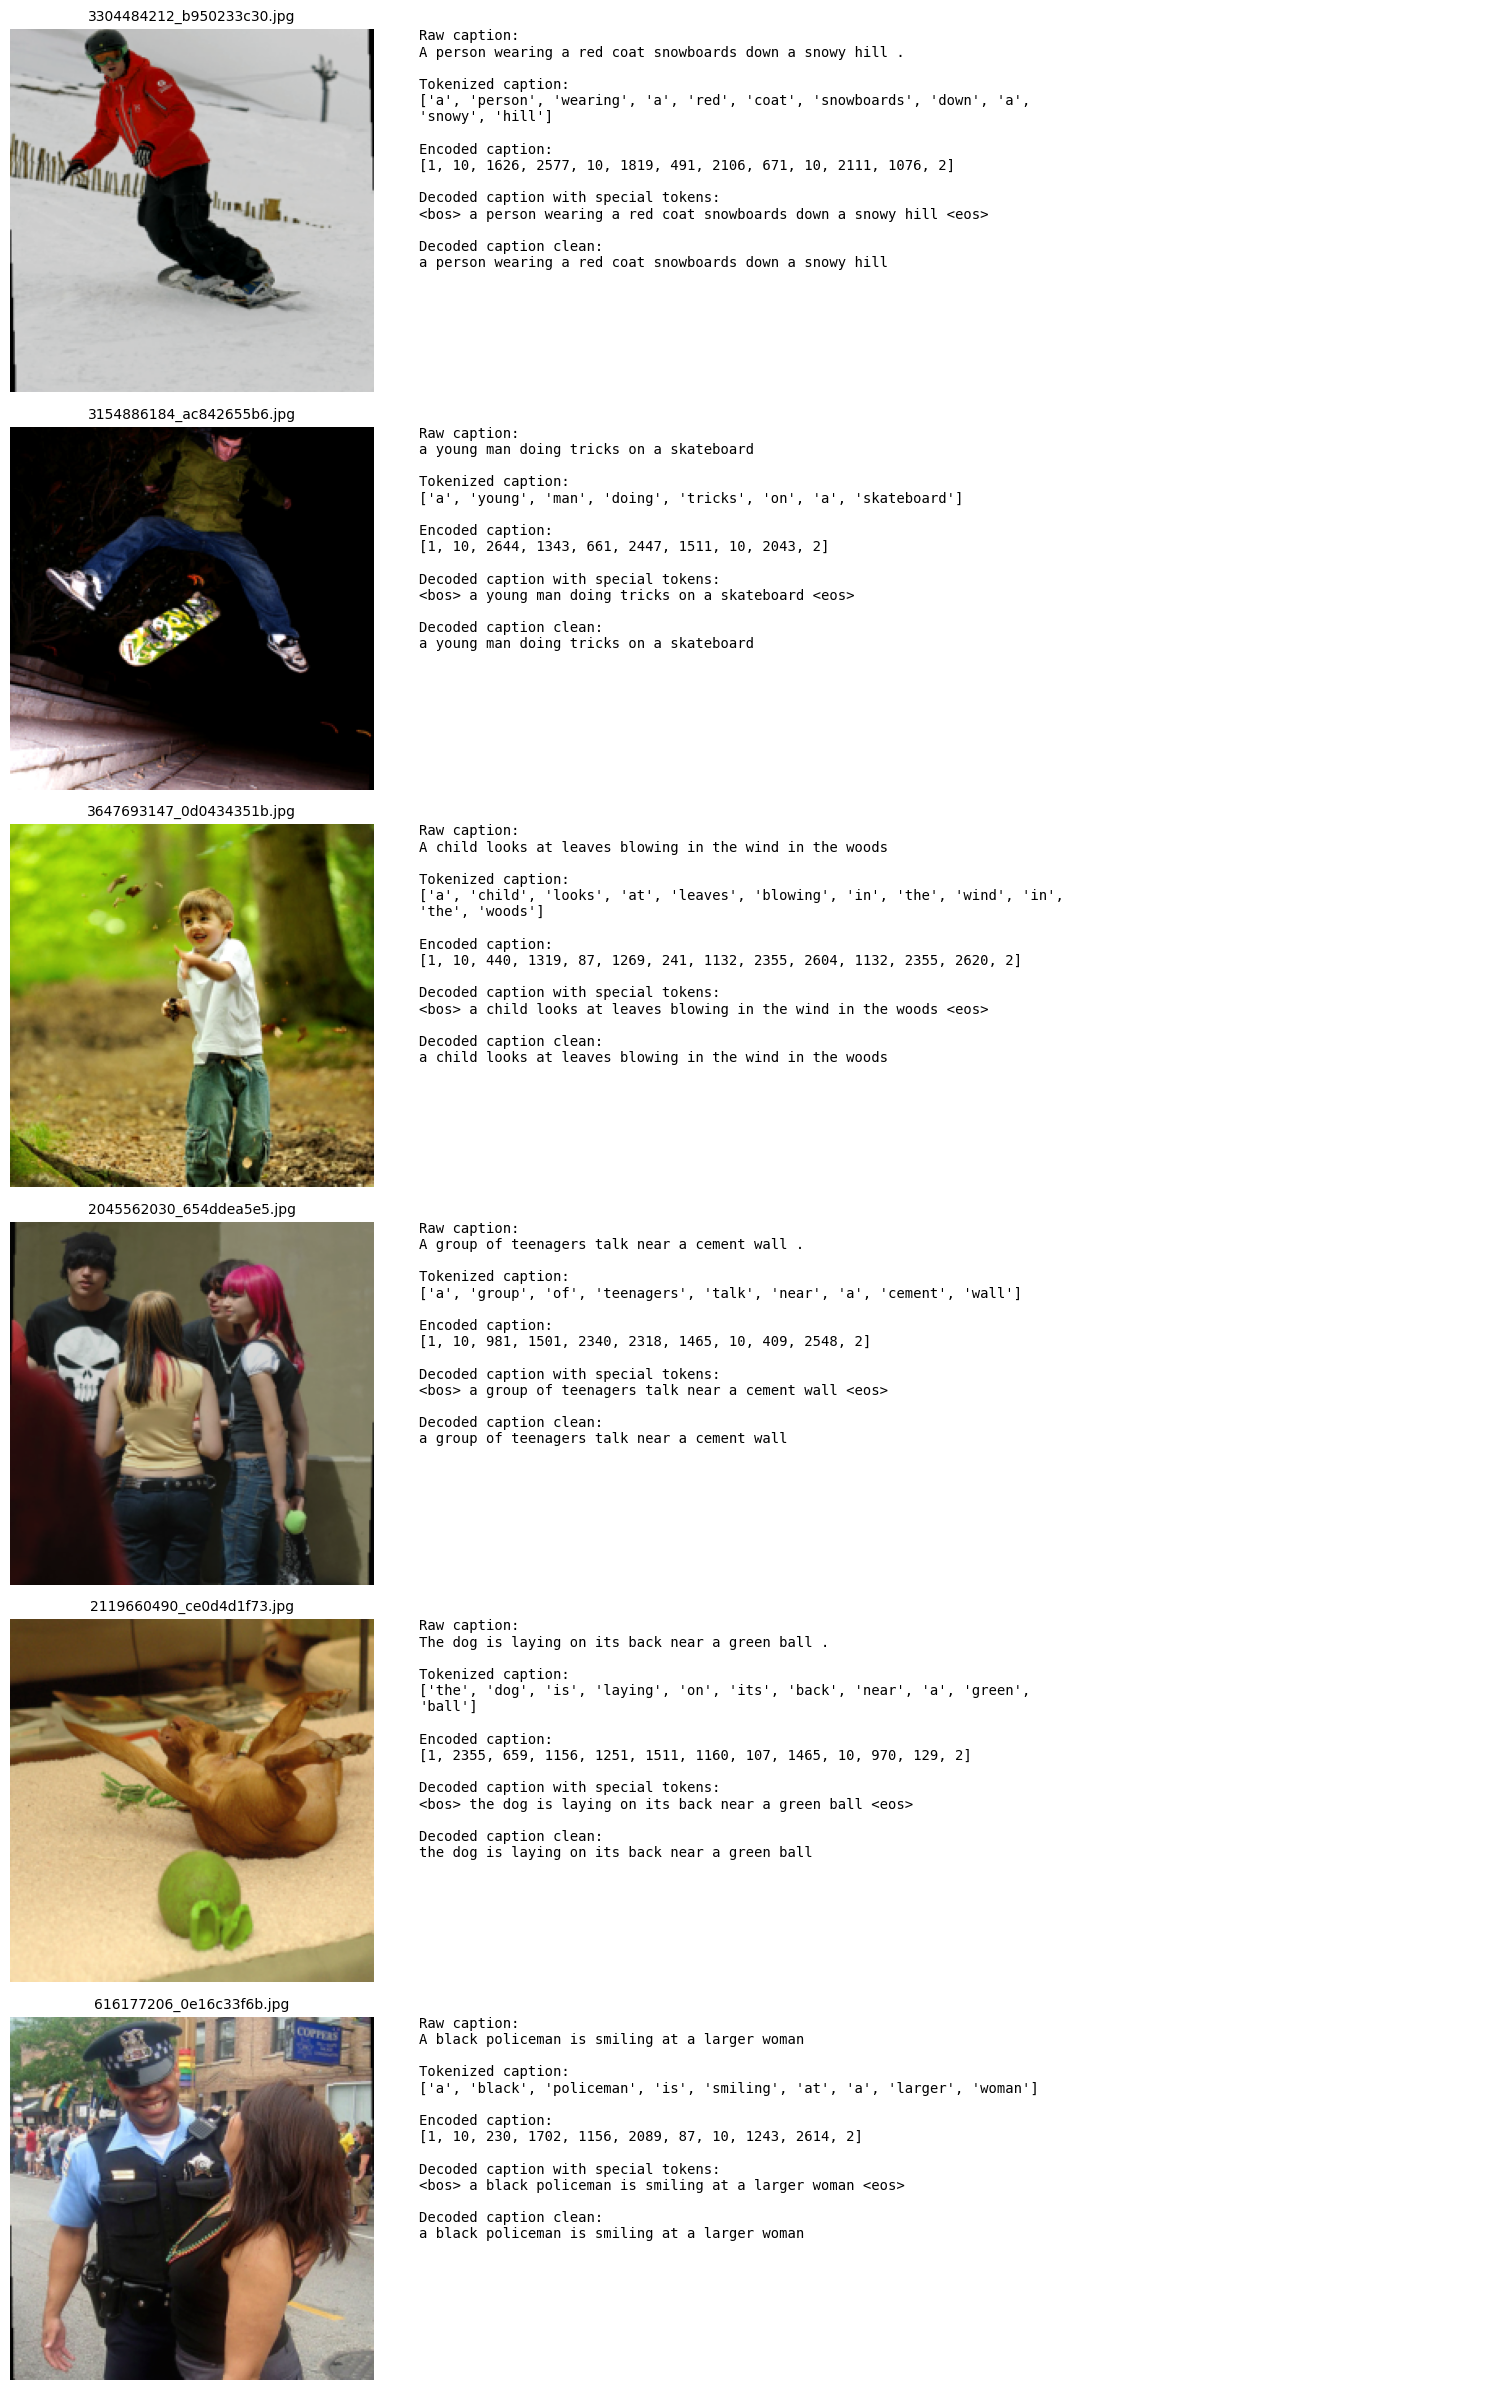

In [7]:
# Grid: images + captions + tokens

# Choosing which loader to inspect:
#   train_loader shows augmented train samples
#   test_loader shows original test samples
viz_loader = train_loader

images, captions, lengths, image_ids, raw_captions = next(iter(viz_loader))

num_examples = 6
n = min(num_examples, len(images))

fig, axes = plt.subplots(
    nrows=n,
    ncols=2,
    figsize=(16, 4 * n),
    gridspec_kw={"width_ratios": [1.1, 2.2]},
    squeeze=False,
)

for idx in range(n):
    image = (
        denormalize_image(images[idx].detach().cpu())
        .permute(1, 2, 0)
        .numpy() # display numpy instead of tensor
    )

    caption_len = int(lengths[idx])
    encoded_caption = captions[idx, :caption_len].tolist()
    tokenized_caption = tokenize(raw_captions[idx])
    decoded_caption_with_specials = tokenizer.decode(
        encoded_caption,
        skip_special_tokens=False,
    )
    decoded_caption_clean = tokenizer.decode(
        encoded_caption,
        skip_special_tokens=True,
    )

    ax_image, ax_text = axes[idx]

    ax_image.imshow(image)
    ax_image.set_title(image_ids[idx], fontsize=10)
    ax_image.axis("off")

    caption_details = "\n\n".join(
        [
            f"Raw caption:\n{textwrap.fill(raw_captions[idx], width=80)}",
            f"Tokenized caption:\n{textwrap.fill(str(tokenized_caption), width=80)}",
            f"Encoded caption:\n{textwrap.fill(str(encoded_caption), width=80)}",
            f"Decoded caption with special tokens:\n{textwrap.fill(decoded_caption_with_specials, width=80)}",
            f"Decoded caption clean:\n{textwrap.fill(decoded_caption_clean, width=80)}",
        ]
    )

    ax_text.axis("off")
    ax_text.text(
        0,
        1,
        caption_details,
        va="top",
        ha="left",
        fontsize=10,
        family="monospace",
    )

plt.tight_layout()
plt.show()

## 3. Shared Utilities
* Shared config objects with type `ICExperimentConfig`
* Helper functions reused across all experiments, e.g.:
    * a common training loop,
    * BLEU computation,
    * visualization helpers.

This way your model models stay directly comparable.


### 3.1 Configs

This notebook reuses the config-based experiment style from **MPW-01-CNN**.
For MPW-03, configs are useful because both captioning models must share the same data setup, tokenizer, training loop, and evaluation procedure, as stated in task requirements.

> See file `ic_configs.py`.

`ICExperimentConfig` contains:

1. `CaptionDataConfig`
   Split names and caption sampling options, e.g. using all captions for training/evaluation and one caption per image for generating examples.

2. `DatasetConfig`
   Image preprocessing settings: image size, ImageNet normalization, and train/test transforms (including data augmentation).

3. `TokenizerConfig`
   Tokenizer setings such as `min_word_freq`, `max_len`, and special tokens.

4. `CaptionModelConfig`
   Model architecture settings: model name, encoder name, pretrained/frozen encoder flag, embedding size, LSTM hidden size, dropout, and tokenizer-dependent IDs.

5. `LossConfig`
   Captioning loss config. The actual loss is token-level cross-entropy with `<pad>` tokens ignored.

6. `OptimizerConfig`
   Optimizer class and parameters, e.g. Adam/AdamW with learning rate and weight decay.

7. `SchedulerConfig`
   Optional LR scheduler settings.

8. `TrainConfig`
   Number of epochs, device, gradient clipping, early stopping, best-metric tracking, and seed.

9. `GenerationConfig`
   Inference settings: maximum caption length and decoding mode (`greedy` or `beam`).

10. `EvaluationConfig`
    Fixed qualitative subset size, BLEU frequency, and optional debug limits.

11. `WandBConfig`
    W&B tracking settings for losses, perplexity, BLEU scores, generated captions, and run summaries.

> Task Description > 6 Training Requirements > Regularization and Overfitting control:
>
>   _Apply appropriate techniques such as dropout, weight decay, early stopping, or augmentation._
>
> These are configured in `CaptionModelConfig`, `OptimizerConfig`, `TrainConfig`, `DatasetConfig`


> Task Description > 6 Training Requirements > Experiment tracking:
>
>   _Use an MLOps or experiment tracking framework such as Weights & Biases (W&B) ..._
>
> Weights & Biases was used, configured in `WandBConfig`

<div class="alert alert-block alert-warning">
Further implementation uses <b>two ICExperimentConfig objects</b>:
<code>cfg_1</code> for Model #1 and <code>cfg_2</code> for Model #2.
They are kept as similar as possible, so the comparison between models is clear.
</div>

In [8]:
# Reproducibility / seed
SEED = 13
seed_everything(SEED)

# Device choice
DEVICE = None
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("device:", DEVICE)

device: cuda


In [9]:
cfg_1 = ic_configs.make_show_and_tell_config()

# =========================================================
# TOKENIZER / VOCABULARY
# =========================================================
cfg_1.tokenizer.tokenizer = tokenizer
cfg_1.tokenizer.min_word_freq = MIN_WORD_FREQ
cfg_1.tokenizer.max_len = MAX_LEN

cfg_1.model = ic_configs.attach_tokenizer_to_model_config(cfg_1.model, tokenizer)

assert cfg_1.model.pad_idx == 0
assert cfg_1.model.bos_idx == 1
assert cfg_1.model.eos_idx == 2
assert cfg_1.model.unk_idx == 3

# =========================================================
# DATA / TRANSFORMS
# =========================================================
cfg_1.dataset.dataset_dir = Path(data_dir)
cfg_1.dataset.image_size = IMAGENET_SIZE
cfg_1.dataset.train_transform = build_train_transforms()
cfg_1.dataset.eval_transform = build_test_transforms()
cfg_1.dataset.normalize_mean = IMAGENET_MEAN
cfg_1.dataset.normalize_std = IMAGENET_STD

cfg_1.caption_data.train_caption_sampling = "all"
cfg_1.caption_data.eval_caption_sampling = "all"
cfg_1.caption_data.generation_caption_sampling = "first"

# =========================================================
# OPTIMIZATION / TRAINING
# =========================================================
cfg_1.optimizer.cls = torch.optim.AdamW
cfg_1.optimizer.kwargs = {
    "lr": 1e-3,
    "weight_decay": 1e-4,
}

cfg_1.scheduler.cls = torch.optim.lr_scheduler.ReduceLROnPlateau
cfg_1.scheduler.kwargs = {
    "mode": "min",
    "factor": 0.35,
    "patience": 5,
}
cfg_1.scheduler.step_metric = "val/loss"

cfg_1.train.epochs = 30
cfg_1.train.device = str(DEVICE)
cfg_1.train.seed = SEED
cfg_1.train.non_blocking = DEVICE.type == "cuda"

cfg_1.train.grad_clip_norm = 1.0

cfg_1.train.best_metric = "val/loss"
cfg_1.train.best_mode = "min"
cfg_1.train.early_stopping = False
cfg_1.train.early_stopping_patience = 7
cfg_1.train.early_stopping_min_delta = 1e-4

# =========================================================
# GENERATION / EVALUATION
# =========================================================
cfg_1.generation.max_len = MAX_LEN
cfg_1.generation.decoding = "greedy"

cfg_1.evaluation.fixed_subset_size = 8
cfg_1.evaluation.compute_bleu_every_n_epochs = 1

# Debug/W&B smoke test: small number
# Final reported evaluation: SET TO None!
cfg_1.evaluation.max_bleu_batches = 2

# =========================================================
# WANDB
# =========================================================
cfg_1.wandb.enabled = True
cfg_1.wandb.project = "MPW-IC"
cfg_1.wandb.entity = "MSE_DeLearn_SPR26"
cfg_1.wandb.mode = "online"

cfg_1.wandb.run_name = "model1" + time.strftime("%Y%m%d-%H%M%S")
cfg_1.wandb.group = "model1"
cfg_1.wandb.tags = [
    "image_captioning",
    "ic",
    "model1",
    "greedy",
]

cfg_1.wandb.metric_allowlist = {
    "train/loss",
    "train/perplexity",
    "val/loss",
    "val/perplexity",
    "val/bleu_1",
    "val/bleu_2",
    "val/bleu_3",
    "val/bleu_4",
    "lr",
    "best/epoch_so_far",
    "best/val_loss_so_far",
}

cfg_1.wandb.summary_allowlist = {
    "best/epoch",
    "best/val/loss",
    "best/val/perplexity",
    "best/val/bleu_1",
    "best/val/bleu_2",
    "best/val/bleu_3",
    "best/val/bleu_4",
    "final/train/loss",
    "final/train/perplexity",
    "final/val/loss",
    "final/val/perplexity",
    "final/val/bleu_1",
    "final/val/bleu_2",
    "final/val/bleu_3",
    "final/val/bleu_4",
    "model/total_params",
    "model/trainable_params",
}

cfg_1.wandb.log_generated_examples = True
cfg_1.wandb.log_attention_examples = False

### 3.2 Reusable Methods

The MPW-03 task description requires to use the same evaluation setup, metrics calculation, and qualitative analysis, therefore shared utilities are used to keep the comparison simple.

#### 3.2.1 Caption Shifting and Teacher Forcing
> Task description > 6 Training Requirements > Teacher forcing:
>
> _Use teacher forcing during training. ...implement: a `forward()` method used during training, a `generate()` method used during inference and evaluation._


During training, captions are shifted for next-token prediction:

```
input:  <bos> a cat plays
target:       a cat plays <eos>
```
**Implemented in:** `ic_utils.py` $\rightarrow$ `split_caption_inputs_targets`



#### 3.2.2 Loss, masking, and perplexity

> Task description > 6 Training Requirements > Loss function and masking:
>
> _Design the loss carefully and properly handle padding and end-of-sequence tokens._

We used token-level cross-entropy over the predicted next-word logits. Additional `<pad>` tokens are ignored as fillers. The loss is **averaged over actual non-padding tokens**, so batches with different caption lengths remain comparable.


> Task description > 7 Evaluation:
>
> _Perplexity should be used as quantitative metrics_

Perplexity is computed as:
$$
Perplexity=exp(Cross Entropy Loss)
$$

**Implemented in:**
`ic_utils.py` $\rightarrow$
- `compute_captioning_loss`
- `perplexity_from_loss`
- `evaluate_loss`

#### 3.2.3 Training loop

The training loop performs [teacher forced training](#321-caption-shifting-and-teacher-forcing), applies the same loss logic for both models, and (optionally) clips gradients.

Gradient clipping is useful for recurrent models because RNN/LSTM training can suffer from unstable gradients (that was discussed on lectures).

**Implemented in:** `ic_utils.py` $\rightarrow$
- `train_one_epoch`
- `move_batch_to_device`
- `extract_logits`

#### 3.2.4 Caption Generation and BLEU

> Task description > 6 Training Requirements > Inference Strategy
>
> _Use greedy decoding for caption generation..._

> Task description > 5 Required Model Architectures > Comparison
>
> Task description > 7 Evaluation
>
> _BLEU-1 to BLEU-4 should be used as quantitative metrics_

For BLEU, generated captions are grouped by `image_id` and compared against all ground-true captions of the same image. This is important because Flickr 8k dataset has multiple captions per image.

**Implemented in:** `ic_utils.py` $\rightarrow$
- `generate_batch_token_ids`
- `truncate_after_eos`
- `decode_token_ids`
- `token_ids_to_bleu_tokens`
- `build_references_by_image_id`
- `evaluate_bleu`

#### 3.2.5 Qualitative analysis subset

> Task description > 7 Evaluation:
>
> _...include a qualitative analysis of generated captions using representative examples._

We collected **a fixed subset of test images** and re-used it for both models. This approach excludes cherry-picking of results and makes the comparison more clear and fair.

**Implemented in:**
`ic_utils.py` $\rightarrow$ `collect_fixed_eval_subset`

## 4. Model 1: Show and Tell

Implement the model described in the [_Show and Tell_](https://arxiv.org/abs/1411.4555) paper.

Task:
1. Record the training behavior,
2. inspect a few generated captions on held-out images,
3. report BLEU on your fixed evaluation subset.

### 4.1 Model 1: Config

In [10]:
# CHANGEABLE PARAMS
BATCH_SIZE = 64
# MODEL #1
cfg_1.model.name = "show_and_tell"
cfg_1.evaluation.max_bleu_batches = None   # debug: 2; report: None
cfg_1.train.epochs = 30                  # debug: 2; report: 10+

# Optimizer --> settings from sweeps
cfg_1.optimizer.kwargs = {
    "lr": 7e-4,
    "weight_decay": 0.0,
}
# Data Augmentation --> settings from sweeps
cfg_1.dataset.train_transform = build_train_transforms(augmentation="medium")

# Dropout --> settings from sweeps
cfg_1.model.dropout = 0.6

# Lr scheduler
cfg_1.scheduler.kwargs = {
    "mode": "min",
    "factor": 0.5,
    "patience": 4,
    "threshold": 1e-3,
    "min_lr": 1e-6,
}

# Early stopping
cfg_1.train.early_stopping = True


cfg_1.wandb.group = "model1"
cfg_1.wandb.run_name = "model1_" + time.strftime("%Y%m%d-%H%M%S")
cfg_1.wandb.tags = ["image_captioning",
    "ic",
    "model1",
    "greedy",
    "tuned model",
    "early stoping",
]

In [11]:
# MODEL 1: Show and Tell
# Source: cfg_1.model - pre-defined config
# !!! These variables are kept only because the captioning_starter.ipynb has them !!!

# ResNet18 produces a 512-dimensional feature vector after global average pooling
ENCODER_DIM = 512

EMBED_DIM = cfg_1.model.embed_dim
DECODER_DIM = cfg_1.model.hidden_dim
DROPOUT = cfg_1.model.dropout
FREEZE_ENCODER = cfg_1.model.freeze_encoder

print("Show and Tell config:")
print(f"  encoder:        {cfg_1.model.encoder_name}")
print(f"  pretrained:     {cfg_1.model.pretrained}")
print(f"  freeze_encoder: {FREEZE_ENCODER}")
print(f"  encoder_dim:    {ENCODER_DIM}")
print(f"  embed_dim:      {EMBED_DIM}")
print(f"  decoder_dim:    {DECODER_DIM}")
print(f"  vocab_size:     {cfg_1.model.vocab_size}")
print(f"  Tuned parameters:")
print(f"  dropout:        {DROPOUT}")
print(f"  lr:             {cfg_1.optimizer.kwargs['lr']}")
print(f"  weight_decay:   {cfg_1.optimizer.kwargs['weight_decay']}")
print(f"  data augmentation: {cfg_1.dataset.train_transform}")

Show and Tell config:
  encoder:        resnet18
  pretrained:     True
  freeze_encoder: True
  encoder_dim:    512
  embed_dim:      256
  decoder_dim:    512
  vocab_size:     2649
  Tuned parameters:
  dropout:        0.6
  lr:             0.0007
  weight_decay:   0.0
  data augmentation: Compose(
    Lambda()
    RandomApply(
    p=0.25
    RandomRotation(degrees=[-3.0, 3.0], interpolation=nearest, expand=False, fill=0)
)
    RandomResizedCrop(size=(224, 224), scale=(0.85, 1.0), ratio=(0.9, 1.1), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.85, 1.15), contrast=(0.85, 1.15), saturation=(0.9, 1.1), hue=(-0.02, 0.02))
    ToTensor()
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
)


### 4.2 Model 1: Classes and Setup

In [12]:
class ShowAndTellEncoder(nn.Module):
    """ResNet18 image encoder producing one global image feature vector."""

    def __init__(
        self,
        encoder_name: str = "resnet18",
        pretrained: bool = True,
        freeze_encoder: bool = True,
    ):
        super().__init__()

        if encoder_name != "resnet18":
            raise ValueError(f"Only resnet18 is supported: {encoder_name}")

        weights = ResNet18_Weights.DEFAULT if pretrained else None
        backbone = resnet18(weights=weights)

        self.output_dim = backbone.fc.in_features  # 512 for ResNet18
        self.freeze_encoder = freeze_encoder

        # remove avg classifier head
        # keep conv body + global avg pooling
        self.cnn = nn.Sequential(*list(backbone.children())[:-1])

        if self.freeze_encoder:
            for param in self.cnn.parameters():
                param.requires_grad = False
            self.cnn.eval()

    def train(self, mode: bool = True):
        """Keep frozen encoder in eval mode so BatchNorm stats do not drift"""
        super().train(mode)
        if self.freeze_encoder:
            self.cnn.eval()
        return self

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        if self.freeze_encoder:
            with torch.no_grad():
                features = self.cnn(images)
        else:
            features = self.cnn(images)

        return features.flatten(start_dim=1)  # [B, 512]


class ShowAndTellCaptioner(nn.Module):
    """
    Show and Tell baseline.

    Training:
        image + decoder_inputs -> next-token logits

    Generation:
        image + <bos> -> token -> token -> ... -> <eos>
    """

    def __init__(self, model_cfg):
        super().__init__()

        required = {
            "vocab_size": model_cfg.vocab_size,
            "pad_idx": model_cfg.pad_idx,
            "bos_idx": model_cfg.bos_idx,
            "eos_idx": model_cfg.eos_idx,
        }
        missing = [name for name, value in required.items() if value is None]
        if missing:
            raise ValueError(f"Model config is missing tokenizer created fields: {missing}")

        self.vocab_size = model_cfg.vocab_size
        self.pad_idx = model_cfg.pad_idx
        self.bos_idx = model_cfg.bos_idx
        self.eos_idx = model_cfg.eos_idx

        self.encoder = ShowAndTellEncoder(
            encoder_name=model_cfg.encoder_name,
            pretrained=model_cfg.pretrained,
            freeze_encoder=model_cfg.freeze_encoder,
        )

        self.image_projection = nn.Linear(self.encoder.output_dim, model_cfg.embed_dim)

        self.embedding = nn.Embedding(
            num_embeddings=model_cfg.vocab_size,
            embedding_dim=model_cfg.embed_dim,
            padding_idx=model_cfg.pad_idx,
        )

        lstm_dropout = model_cfg.dropout if model_cfg.num_lstm_layers > 1 else 0.0
        self.lstm = nn.LSTM(
            input_size=model_cfg.embed_dim,
            hidden_size=model_cfg.hidden_dim,
            num_layers=model_cfg.num_lstm_layers,
            batch_first=True,
            dropout=lstm_dropout,
        )

        self.dropout = nn.Dropout(model_cfg.dropout)
        self.output_layer = nn.Linear(model_cfg.hidden_dim, model_cfg.vocab_size)

    def forward(self, images: torch.Tensor, captions: torch.Tensor) -> torch.Tensor:
        """
        Args:
            images: [B, 3, H, W]
            captions: [B, T] decoder inputs, usually captions[:, :-1]

        Returns:
            logits: [B, T, vocab_size]
        """
        image_features = self.encoder(images)                         # [B, 512]
        image_embedding = self.image_projection(image_features)        # [B, E]
        image_embedding = image_embedding.unsqueeze(1)                 # [B, 1, E]

        word_embeddings = self.embedding(captions)                     # [B, T, E]

        # paper-style conditioning: image embedding is the first LSTM input
        lstm_inputs = torch.cat([image_embedding, word_embeddings], dim=1)  # [B, T+1, E]

        lstm_outputs, _ = self.lstm(lstm_inputs)                       # [B, T+1, H]

        # ignore output after image input; use outputs after caption-prefix tokens
        token_outputs = lstm_outputs[:, 1:, :]                         # [B, T, H]

        logits = self.output_layer(self.dropout(token_outputs))         # [B, T, vocab_size]
        return logits

    @torch.no_grad()
    def generate(
        self,
        images: torch.Tensor,
        max_len: int = 35,
        bos_idx: int | None = None,
        eos_idx: int | None = None,
    ) -> torch.Tensor:
        """
        Greedy decoding.

        Returns:
            generated token ids without <bos>, but possibly including <eos>.
            Shape: [B, <= max_len]
        """
        self.eval()

        bos_idx = self.bos_idx if bos_idx is None else bos_idx
        eos_idx = self.eos_idx if eos_idx is None else eos_idx

        batch_size = images.size(0)
        device = images.device

        image_features = self.encoder(images)
        image_embedding = self.image_projection(image_features).unsqueeze(1)

        # first LSTM step consumes image embedding
        _, hidden = self.lstm(image_embedding)

        current_tokens = torch.full(
            (batch_size,),
            fill_value=bos_idx,
            dtype=torch.long,
            device=device,
        )

        generated = []
        finished = torch.zeros(batch_size, dtype=torch.bool, device=device)
        eos_fill = torch.full_like(current_tokens, fill_value=eos_idx)

        for _ in range(max_len):
            word_embedding = self.embedding(current_tokens).unsqueeze(1)
            output, hidden = self.lstm(word_embedding, hidden)

            logits = self.output_layer(output.squeeze(1))
            next_tokens = logits.argmax(dim=-1)

            # add eos after sequence is finished
            next_tokens = torch.where(finished, eos_fill, next_tokens)

            generated.append(next_tokens)
            finished |= next_tokens.eq(eos_idx)

            if finished.all():
                break

            current_tokens = next_tokens

        if not generated:
            return torch.empty(batch_size, 0, dtype=torch.long, device=device)

        return torch.stack(generated, dim=1)


model_1 = ShowAndTellCaptioner(cfg_1.model).to(DEVICE)

optimizer_1 = cfg_1.optimizer.cls(
    (p for p in model_1.parameters() if p.requires_grad),
    **cfg_1.optimizer.kwargs,
)

scheduler_1 = (
    None
    if cfg_1.scheduler.cls is None
    else cfg_1.scheduler.cls(optimizer_1, **cfg_1.scheduler.kwargs)
)

total_params_1 = sum(p.numel() for p in model_1.parameters())
trainable_params_1 = sum(p.numel() for p in model_1.parameters() if p.requires_grad)

print(model_1)
print(f"Total params:     {total_params_1:,}")
print(f"Trainable params: {trainable_params_1:,}")

ShowAndTellCaptioner(
  (encoder): ShowAndTellEncoder(
    (cnn): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): Batch

### 4.3 Model 1: Training, Caption generation, and Evaluation

**Note**:
The code cell template below asked these:
> _"Add **the training loop**, caption generation, **evaluation** and metric calculation logic for Model 1 here and in the following cells."_

But [3. Shared Utilities](#3-shared-utilities) section asked these:

> _"Use this section for shared config and helper functions reused across all experiments._
>
> _For example define **a common training loop, BLEU computation or visualization helpers here.** This way your model models stay directly comparable."_

<div class="alert alert-block alert-warning">
These requirements partially contradict each other. So we decided <b>to keep train/eval/BLEU logic as shared utilities </b>
</div>



#### W&B sweep for Hyperparameter tuning
To find suitable hyperparameters we used the W&B sweep functionality. The following Hyperparameters are to be tuned:
* Learning rate (LR)
* Weight decay (WD)
* strength of the data augmentation (DA)
* Dropout (DO)

The tunung will take place in three steps, first tuning the LR and WD and then with them fixed tune the DA and then DO.\
For the sweep we usewd the `grid`-search method, since its functionality is easier to interpret and reproducible. Eventough the `bayes` method would wioth higher probability lead to the "better" hyperparameters while being more efficient (https://en.wikipedia.org/wiki/Bayesian_optimization).

<b>Tuning LR and WD:</b>


For this part we used the DA-setting "medium", since we want to use data augmentation later on.


1. Sweep:

|Hyperparameters|Values                 |
|--------------:|----------------------:|
|LR             | 3e-3, 1e-3, 3e-4, 1e-4|
|WD             |  1e-3, 1e-4, 1e-5, 0.0|

2. Sweep:

|Hyperparameters|Values            |
|--------------:|-----------------:|
|LR             |1.5e-3, 1e-3, 7e-4|
|WD             |   1e-5, 1e-6, 0.0|


In [15]:
sweep_config = {
    "method": "grid", # alternatives: "random", "bayes"
    "metric": {
        "name": "val/loss",
        "goal": "minimize",
    },
    "parameters": {
        "lr": {
            "values": [7e-4, 1e-3, 1.5e-3]
        },
        "weight_decay": {
            "values": [0, 1e-6, 1e-5]
        },
    },
}

In [16]:
# RUN ONLY ONCE TO CREATE SWEEP!!!
sweep_id = wandb.sweep(
    sweep=sweep_config,
    project="MPW-IC",
    entity="MSE_DeLearn_SPR26", 
)

print(sweep_id)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\lucas\_netrc.


Create sweep with ID: emigi0vz
Sweep URL: https://wandb.ai/MSE_DeLearn_SPR26/MPW-IC/sweeps/emigi0vz
emigi0vz


In [17]:
sweep_id = "MSE_DeLearn_SPR26/MPW-IC/emigi0vz"

In [18]:
def sweep_train():
    bs = 64

    with wandb.init(reinit=True) as wandb_run:

        sweep_cfg = wandb.config

        seed_everything(13)

        # fresh config per run
        cfg_1 = ic_configs.make_show_and_tell_config()
        cfg_1.train.device = "cuda"
        cfg_1.train.epochs = 20  # shorter for sweep
        cfg_1.train.early_stopping = False
        cfg_1.train.best_metric = "val/bleu4"
        cfg_1.train.best_mode = "max"
        cfg_1.evaluation.compute_bleu_every_n_epochs = 2
        cfg_1.evaluation.max_bleu_batches = 5

        cfg_1.dataset.dataset_dir = Path(data_dir)

        # inject sweep values
        cfg_1.optimizer.kwargs["lr"] = sweep_cfg.lr
        cfg_1.optimizer.kwargs["weight_decay"] = sweep_cfg.weight_decay

        # transforms
        cfg_1.dataset.train_transform = build_train_transforms()
        cfg_1.dataset.eval_transform = build_test_transforms()

        # tokenizer
        tokenizer = build_tokenizer_from_split(
            split=cfg_1.caption_data.train_split,
            data_dir=cfg_1.dataset.dataset_dir,
            min_freq=cfg_1.tokenizer.min_word_freq,
        )

        ic_configs.attach_tokenizer_to_model_config(cfg_1.model, tokenizer)

        # loaders
        train_loader = create_caption_dataloader(
            split=cfg_1.caption_data.train_split,
            data_dir=cfg_1.dataset.dataset_dir,
            tokenizer=tokenizer,
            transform=cfg_1.dataset.train_transform,
            batch_size=bs,
            max_len=cfg_1.tokenizer.max_len,
            caption_sampling=cfg_1.caption_data.train_caption_sampling,
            num_workers=0,
            pin_memory=True,
        )

        test_loader = create_caption_dataloader(
            split=cfg_1.caption_data.test_split,
            data_dir=cfg_1.dataset.dataset_dir,
            tokenizer=tokenizer,
            transform=cfg_1.dataset.eval_transform,
            batch_size=bs,
            max_len=cfg_1.tokenizer.max_len,
            caption_sampling=cfg_1.caption_data.eval_caption_sampling,
            shuffle=False,
            num_workers=0,
            pin_memory=True,
        )

        test_image_loader = create_caption_dataloader(
            split=cfg_1.caption_data.test_split,
            data_dir=cfg_1.dataset.dataset_dir,
            tokenizer=tokenizer,
            transform=cfg_1.dataset.eval_transform,
            batch_size=bs,
            max_len=cfg_1.tokenizer.max_len,
            caption_sampling=cfg_1.caption_data.generation_caption_sampling,
            shuffle=False,
            num_workers=0,
            pin_memory=True,
        )

        references_by_image_id = build_references_by_image_id(test_loader)

        # fresh model per sweep run
        model_1 = ShowAndTellCaptioner(cfg_1.model).to(DEVICE)

        optimizer_1 = cfg_1.optimizer.cls(
            model_1.parameters(),
            **cfg_1.optimizer.kwargs,
        )

        for epoch in range(1, cfg_1.train.epochs + 1):

            train_metrics = train_one_epoch(
                model=model_1,
                loader=train_loader,
                optimizer=optimizer_1,
                cfg=cfg_1,
                desc=f"sweep train {epoch}/{cfg_1.train.epochs}",
            )

            val_metrics = evaluate_loss(
                model=model_1,
                loader=test_loader,
                cfg=cfg_1,
                desc=f"sweep eval {epoch}/{cfg_1.train.epochs}",
            )

            metrics = {
                "epoch": epoch,
                "train/loss": train_metrics["loss"],
                "train/perplexity": train_metrics["perplexity"],
                "val/loss": val_metrics["loss"],
                "val/perplexity": val_metrics["perplexity"],
                "lr": optimizer_1.param_groups[0]["lr"],
                "weight_decay": cfg_1.optimizer.kwargs["weight_decay"],
            }

            # BLEU-scores
            if epoch % cfg_1.evaluation.compute_bleu_every_n_epochs == 0:

                bleu_metrics = evaluate_bleu(
                    model=model_1,
                    image_loader=test_image_loader,
                    references_by_image_id=references_by_image_id,
                    tokenizer=tokenizer,
                    cfg=cfg_1,
                    max_batches=cfg_1.evaluation.max_bleu_batches,
                )

                metrics.update({
                    "val/bleu1": bleu_metrics["bleu_1"],
                    "val/bleu2": bleu_metrics["bleu_2"],
                    "val/bleu3": bleu_metrics["bleu_3"],
                    "val/bleu4": bleu_metrics["bleu_4"],
                })

            wandb.log(metrics)

            print(
                f"epoch={epoch:03d} | "
                f"lr={cfg_1.optimizer.kwargs['lr']} | "
                f"wd={cfg_1.optimizer.kwargs['weight_decay']} | "
                f"train_loss={metrics['train/loss']:.4f} | "
                f"val_loss={metrics['val/loss']:.4f}"
            )

In [19]:
wandb.agent(
    sweep_id=sweep_id,
    function=sweep_train,
    # count=1, # test one run for debugging
)

wandb: Agent Starting Run: 9ynkk2e5 with config:
wandb: 	lr: 0.0007
wandb: 	weight_decay: 0
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\lucas\_netrc.
wandb: Currently logged in as: lucas-j-keller98 (MSE_DeLearn_SPR26) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


build references:   0%|          | 0/127 [00:00<?, ?it/s]

sweep train 1/20:   0%|          | 0/506 [00:00<?, ?it/s]

sweep eval 1/20:   0%|          | 0/127 [00:00<?, ?it/s]

epoch=001 | lr=0.0007 | wd=0 | train_loss=4.0127 | val_loss=3.4220


...

sweep eval 20/20:   0%|          | 0/127 [00:00<?, ?it/s]

BLEU generation:   0%|          | 0/26 [00:00<?, ?it/s]

epoch=020 | lr=0.0015 | wd=1e-05 | train_loss=1.8865 | val_loss=3.0025


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/loss,█▆▅▄▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁
train/perplexity,█▄▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val/bleu1,▁▆▇▇█▇▇▇▇▇
val/bleu2,▁▅▇▇█▇▇▇█▇
val/bleu3,▁▅▇▇█▇▇██▇
val/bleu4,▁▄▆▇█▇▇██▇
val/loss,█▄▃▂▁▁▁▁▁▁▂▂▂▂▃▃▄▄▄▄
val/perplexity,█▄▂▂▁▁▁▁▁▁▁▂▂▂▂▃▃▃▃▄
+1,...


wandb: Sweep Agent: Waiting for job.
wandb: Sweep Agent: Exiting.


<b>Sweep Results:</b>
|Hyperparameter| Value|
|-------------:|-----:|
|Best LR       |`7e-4`|
|Best WD       | `0.0`|

(full insight can be seen in W&B sweeps g0ak4kpw & emigi0vz)\

<b>Tune DA strength:</b>

In this part we will conduct a small sweep over the following three settings:

- `none`: only resize and normalize.
- `light`: resize, random crop, horizointal flip.
- `medium`: random rotation, random resizecrop, random horizontal flip, color jitter.

The actual values are defined in the `build_train_transforms`and ar not tuned individually in this short tuning step.

In [16]:
sweep_config = {
    "method": "grid", # alternatives: "random", "bayes"
    "metric": {
        "name": "val/loss",
        "goal": "minimize",
    },
    "parameters": {
        "augmentation": {
            "values": ["none", "light", "medium",]
        },
    },
}

In [17]:
# RUN ONLY ONCE TO CREATE SWEEP!!!
sweep_id = wandb.sweep(
    sweep=sweep_config,
    project="MPW-IC",
    entity="MSE_DeLearn_SPR26", 
)

print(sweep_id)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\lucas\_netrc.


Create sweep with ID: xbmsqi6o
Sweep URL: https://wandb.ai/MSE_DeLearn_SPR26/MPW-IC/sweeps/xbmsqi6o
xbmsqi6o


In [18]:
sweep_id = "MSE_DeLearn_SPR26/MPW-IC/xbmsqi6o"

In [ ]:
def sweep_train():
    bs = 64

    with wandb.init(reinit=True) as wandb_run:

        class DummyCfg:
            augmentation = "medium"

        sweep_cfg = DummyCfg()

        seed_everything(13)

        # fresh config per run
        cfg_1 = ic_configs.make_show_and_tell_config()
        cfg_1.train.device = "cuda"
        cfg_1.train.epochs = 20  # shorter for sweep

        # LR and WD obtained from prior sweeps
        cfg_1.optimizer.kwargs["lr"] = 7e-4
        cfg_1.optimizer.kwargs["weight_decay"] = 0.0

        cfg_1.train.early_stopping = False
        cfg_1.train.best_metric = "val/loss"
        cfg_1.train.best_mode = "min"
        cfg_1.evaluation.compute_bleu_every_n_epochs = 2
        cfg_1.evaluation.max_bleu_batches = 10

        cfg_1.dataset.dataset_dir = Path(data_dir)

        # transforms
        # inject sweep values
        cfg_1.dataset.train_transform = build_train_transforms("medium")
        cfg_1.dataset.eval_transform = build_test_transforms()

        # tokenizer
        tokenizer = build_tokenizer_from_split(
            split=cfg_1.caption_data.train_split,
            data_dir=cfg_1.dataset.dataset_dir,
            min_freq=cfg_1.tokenizer.min_word_freq,
        )

        ic_configs.attach_tokenizer_to_model_config(cfg_1.model, tokenizer)

        # loaders
        train_loader = create_caption_dataloader(
            split=cfg_1.caption_data.train_split,
            data_dir=cfg_1.dataset.dataset_dir,
            tokenizer=tokenizer,
            transform=cfg_1.dataset.train_transform,
            batch_size=bs,
            max_len=cfg_1.tokenizer.max_len,
            caption_sampling=cfg_1.caption_data.train_caption_sampling,
            num_workers=0,
            pin_memory=True,
        )

        test_loader = create_caption_dataloader(
            split=cfg_1.caption_data.test_split,
            data_dir=cfg_1.dataset.dataset_dir,
            tokenizer=tokenizer,
            transform=cfg_1.dataset.eval_transform,
            batch_size=bs,
            max_len=cfg_1.tokenizer.max_len,
            caption_sampling=cfg_1.caption_data.eval_caption_sampling,
            shuffle=False,
            num_workers=0,
            pin_memory=True,
        )

        test_image_loader = create_caption_dataloader(
            split=cfg_1.caption_data.test_split,
            data_dir=cfg_1.dataset.dataset_dir,
            tokenizer=tokenizer,
            transform=cfg_1.dataset.eval_transform,
            batch_size=bs,
            max_len=cfg_1.tokenizer.max_len,
            caption_sampling=cfg_1.caption_data.generation_caption_sampling,
            shuffle=False,
            num_workers=0,
            pin_memory=True,
        )

        references_by_image_id = build_references_by_image_id(test_loader)

        # fresh model per sweep run
        model_1 = ShowAndTellCaptioner(cfg_1.model).to(DEVICE)

        optimizer_1 = cfg_1.optimizer.cls(
            (p for p in model_1.parameters() if p.requires_grad),
            **cfg_1.optimizer.kwargs,
        )

        best_value = None
        best_epoch = None

        for epoch in range(1, cfg_1.train.epochs + 1):

            train_metrics = train_one_epoch(
                model=model_1,
                loader=train_loader,
                optimizer=optimizer_1,
                cfg=cfg_1,
                desc=f"sweep train {epoch}/{cfg_1.train.epochs}",
            )

            val_metrics = evaluate_loss(
                model=model_1,
                loader=test_loader,
                cfg=cfg_1,
                desc=f"sweep eval {epoch}/{cfg_1.train.epochs}",
            )

            metrics = {
                "epoch": epoch,
                "train/loss": train_metrics["loss"],
                "train/perplexity": train_metrics["perplexity"],
                "val/loss": val_metrics["loss"],
                "val/perplexity": val_metrics["perplexity"],
                "lr": optimizer_1.param_groups[0]["lr"],
                "weight_decay": cfg_1.optimizer.kwargs["weight_decay"],
                "augmentation": sweep_cfg.augmentation,
            }

            # BLEU-scores
            if epoch % cfg_1.evaluation.compute_bleu_every_n_epochs == 0:

                bleu_metrics = evaluate_bleu(
                    model=model_1,
                    image_loader=test_image_loader,
                    references_by_image_id=references_by_image_id,
                    tokenizer=tokenizer,
                    cfg=cfg_1,
                    max_batches=cfg_1.evaluation.max_bleu_batches,
                )

                metrics.update({
                    "val/bleu1": bleu_metrics["bleu_1"],
                    "val/bleu2": bleu_metrics["bleu_2"],
                    "val/bleu3": bleu_metrics["bleu_3"],
                    "val/bleu4": bleu_metrics["bleu_4"],
                })

            current_value = metrics.get(cfg_1.train.best_metric)

            if current_value is not None:
                if (
                    best_value is None
                    or (
                        cfg_1.train.best_mode == "min"
                        and current_value < best_value
                    )
                    or (
                        cfg_1.train.best_mode == "max"
                        and current_value > best_value
                    )
                ):
                    best_value = current_value
                    best_epoch = epoch

            metrics["best/epoch_so_far"] = best_epoch
            metrics["best/value_so_far"] = best_value

            wandb.log(metrics)

            print(
                f"aug={sweep_cfg.augmentation} |"
                f"epoch={epoch:03d} | "
                f"lr={cfg_1.optimizer.kwargs['lr']} | "
                f"wd={cfg_1.optimizer.kwargs['weight_decay']} | "
                f"train_loss={metrics['train/loss']:.4f} | "
                f"val_loss={metrics['val/loss']:.4f}"
            )

        wandb_run.summary["best/epoch"] = best_epoch
        wandb_run.summary["best/value"] = best_value
        wandb_run.summary["augmentation"] = sweep_cfg.augmentation

In [ ]:
wandb.agent(
    sweep_id=sweep_id,
    function=sweep_train,
    # count=1, # test one run for debugging
)

wandb: Agent Starting Run: ka8itk8v with config:
wandb: 	augmentation: none
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\lucas\_netrc.
wandb: Currently logged in as: lucas-j-keller98 (MSE_DeLearn_SPR26) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


build references:   0%|          | 0/127 [00:00<?, ?it/s]

sweep train 1/20:   0%|          | 0/506 [00:00<?, ?it/s]

sweep eval 1/20:   0%|          | 0/127 [00:00<?, ?it/s]

aug=none |epoch=001 | lr=0.0007 | wd=0.0 | train_loss=4.0126 | val_loss=3.4217


...

aug=medium |epoch=018 | lr=0.0007 | wd=0.0 | train_loss=1.9979 | val_loss=2.8075


sweep train 19/20:   0%|          | 0/506 [00:00<?, ?it/s]

sweep eval 19/20:   0%|          | 0/127 [00:00<?, ?it/s]

aug=medium |epoch=019 | lr=0.0007 | wd=0.0 | train_loss=1.9638 | val_loss=2.8177


sweep train 20/20:   0%|          | 0/506 [00:00<?, ?it/s]

<b>Sweep Results:</b>

The best result delivered the setting `medium`. (the runs can be seen in W&B sweep xbmsqi6o)

<b>Tune the LSTM dropout:</b>

Here we make a short sweep through three DO vlues:
* `0.3`
* `0.5`
* `0.6`

Higher values wouldn't make sense since th Network conist of a large frozen part that does/cannot change and there only is one LSTM-Layer. IN this particular case too much regularization would hurt performance.

In [13]:
sweep_config = {
    "method": "grid",
    "metric": {
        "name": "val/loss",
        "goal": "minimize",
    },
    "parameters": {
        "dropout": {
            "values": [0.3, 0.5, 0.6]
        }
    },
}

In [14]:
# RUN ONLY ONCE TO CREATE SWEEP!!!
sweep_id = wandb.sweep(
    sweep=sweep_config,
    project="MPW-IC",
    entity="MSE_DeLearn_SPR26", 
)

print(sweep_id)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\lucas\_netrc.


Create sweep with ID: scqzb8ly
Sweep URL: https://wandb.ai/MSE_DeLearn_SPR26/MPW-IC/sweeps/scqzb8ly
scqzb8ly


In [15]:
sweep_id = "MSE_DeLearn_SPR26/MPW-IC/scqzb8ly"

In [16]:
def sweep_train():
    bs = 64

    with wandb.init(reinit=True) as wandb_run:

        sweep_cfg = wandb.config

        seed_everything(13)

        # fresh config per run
        cfg_1 = ic_configs.make_show_and_tell_config()
        cfg_1.train.device = "cuda"
        cfg_1.train.epochs = 20  # shorter for sweep
        cfg_1.train.early_stopping = False
        cfg_1.train.best_metric = "val/loss"
        cfg_1.train.best_mode = "min"
        cfg_1.evaluation.compute_bleu_every_n_epochs = 2
        cfg_1.evaluation.max_bleu_batches = 10

        cfg_1.dataset.dataset_dir = Path(data_dir)

        # initiate dropout from sweep config
        cfg_1.model.dropout = sweep_cfg.dropout

        # LR and WD obtained from prior sweeps
        cfg_1.optimizer.kwargs["lr"] = 7e-4
        cfg_1.optimizer.kwargs["weight_decay"] = 0.0

        # transforms
        cfg_1.dataset.train_transform = build_train_transforms("medium") # from prior sweeps
        cfg_1.dataset.eval_transform = build_test_transforms()

        # tokenizer
        tokenizer = build_tokenizer_from_split(
            split=cfg_1.caption_data.train_split,
            data_dir=cfg_1.dataset.dataset_dir,
            min_freq=cfg_1.tokenizer.min_word_freq,
        )

        ic_configs.attach_tokenizer_to_model_config(cfg_1.model, tokenizer)

        # loaders
        train_loader = create_caption_dataloader(
            split=cfg_1.caption_data.train_split,
            data_dir=cfg_1.dataset.dataset_dir,
            tokenizer=tokenizer,
            transform=cfg_1.dataset.train_transform,
            batch_size=bs,
            max_len=cfg_1.tokenizer.max_len,
            caption_sampling=cfg_1.caption_data.train_caption_sampling,
            num_workers=0,
            pin_memory=True,
        )

        test_loader = create_caption_dataloader(
            split=cfg_1.caption_data.test_split,
            data_dir=cfg_1.dataset.dataset_dir,
            tokenizer=tokenizer,
            transform=cfg_1.dataset.eval_transform,
            batch_size=bs,
            max_len=cfg_1.tokenizer.max_len,
            caption_sampling=cfg_1.caption_data.eval_caption_sampling,
            shuffle=False,
            num_workers=0,
            pin_memory=True,
        )

        test_image_loader = create_caption_dataloader(
            split=cfg_1.caption_data.test_split,
            data_dir=cfg_1.dataset.dataset_dir,
            tokenizer=tokenizer,
            transform=cfg_1.dataset.eval_transform,
            batch_size=bs,
            max_len=cfg_1.tokenizer.max_len,
            caption_sampling=cfg_1.caption_data.generation_caption_sampling,
            shuffle=False,
            num_workers=0,
            pin_memory=True,
        )

        references_by_image_id = build_references_by_image_id(test_loader)

        # fresh model per sweep run
        model_1 = ShowAndTellCaptioner(cfg_1.model).to(DEVICE)

        optimizer_1 = cfg_1.optimizer.cls(
            (p for p in model_1.parameters() if p.requires_grad),
            **cfg_1.optimizer.kwargs,
        )

        for epoch in range(1, cfg_1.train.epochs + 1):

            train_metrics = train_one_epoch(
                model=model_1,
                loader=train_loader,
                optimizer=optimizer_1,
                cfg=cfg_1,
                desc=f"sweep train {epoch}/{cfg_1.train.epochs}",
            )

            val_metrics = evaluate_loss(
                model=model_1,
                loader=test_loader,
                cfg=cfg_1,
                desc=f"sweep eval {epoch}/{cfg_1.train.epochs}",
            )

            metrics = {
                "epoch": epoch,
                "train/loss": train_metrics["loss"],
                "train/perplexity": train_metrics["perplexity"],
                "val/loss": val_metrics["loss"],
                "val/perplexity": val_metrics["perplexity"],
                "lr": optimizer_1.param_groups[0]["lr"],
                "weight_decay": cfg_1.optimizer.kwargs["weight_decay"],
            }

            # BLEU-scores
            if epoch % cfg_1.evaluation.compute_bleu_every_n_epochs == 0:

                bleu_metrics = evaluate_bleu(
                    model=model_1,
                    image_loader=test_image_loader,
                    references_by_image_id=references_by_image_id,
                    tokenizer=tokenizer,
                    cfg=cfg_1,
                    max_batches=cfg_1.evaluation.max_bleu_batches,
                )

                metrics.update({
                    "val/bleu1": bleu_metrics["bleu_1"],
                    "val/bleu2": bleu_metrics["bleu_2"],
                    "val/bleu3": bleu_metrics["bleu_3"],
                    "val/bleu4": bleu_metrics["bleu_4"],
                })

            wandb.log(metrics)

            print(
                f"epoch={epoch:03d} | "
                f"lr={cfg_1.optimizer.kwargs['lr']} | "
                f"wd={cfg_1.optimizer.kwargs['weight_decay']} | "
                f"train_loss={metrics['train/loss']:.4f} | "
                f"val_loss={metrics['val/loss']:.4f}"
            )

In [17]:
wandb.agent(
    sweep_id=sweep_id,
    function=sweep_train,
    # count=1, # test one run for debugging
)

wandb: Agent Starting Run: gnqcjrln with config:
wandb: 	dropout: 0.3
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\lucas\_netrc.
wandb: Currently logged in as: lucas-j-keller98 (MSE_DeLearn_SPR26) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


build references:   0%|          | 0/127 [00:00<?, ?it/s]

sweep train 1/20:   0%|          | 0/506 [00:00<?, ?it/s]

sweep eval 1/20:   0%|          | 0/127 [00:00<?, ?it/s]

epoch=001 | lr=0.0007 | wd=0.0 | train_loss=3.9480 | val_loss=3.3842


...

sweep eval 20/20:   0%|          | 0/127 [00:00<?, ?it/s]

BLEU generation:   0%|          | 0/26 [00:00<?, ?it/s]

epoch=020 | lr=0.0007 | wd=0.0 | train_loss=2.0994 | val_loss=2.7980


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/loss,█▆▅▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁
train/perplexity,█▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val/bleu1,▁▄▄▇█▇█▇█▇
val/bleu2,▁▄▄▇█▇█▇█▇
val/bleu3,▁▄▄▇█▇█▇█▇
val/bleu4,▁▄▄▇█▇█▇█▇
val/loss,█▅▄▃▂▂▂▁▁▁▁▁▁▁▁▁▂▁▁▂
val/perplexity,█▅▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+1,...


wandb: Sweep Agent: Waiting for job.
wandb: Sweep Agent: Exiting.


<b>Sweep Results:</b>

The best results were achieved with the drouout rate of `0.6`. (fulll insight in W&B sweep scqzb8ly, somehow the last run got deleted - but believe me it was by a small margin better than `0.5`)

#### Final results of hyperparameter tuning:

To summarize the following table shows all the tuned hyparparameters and it's values:

|Hyperparameter|   Value|
|-------------:|-------:|
| LR           |  `7e-4`|
| WD           |   `0.0`|
| DA           |`medium`|
| DO           |   `0.6`|

With these values a regular model is fully traind to observe its training behaviour and early stopping is then applied on the final model to prevent overfitting. Which was already observed in the sweeps. Additionaly we are using a Lr-scheduler that reduces the LR by a factor of `0.5` if the threshold of `1e-3` is not exceede for `4` epochs (with a fixed min lr-rate of `1e-6`). Even though we saw that after 20 epoch the model ends up in an overfitting regime we set the number of training epochs to 30, because the BLEU-metrics tends to stabelise later than the validation-loss and -perplexity. 

In [13]:
# ensure shared eval objects exist
if "references_by_image_id" not in globals():
    references_by_image_id = build_references_by_image_id(test_loader)

if "fixed_eval_subset" not in globals():
    fixed_eval_subset = collect_fixed_eval_subset(test_image_loader, cfg_1)


# WandB
wandb_run = None
if cfg_1.wandb.enabled and cfg_1.wandb.mode != "disabled":
    import wandb

    wandb_run = wandb.init(
        project=cfg_1.wandb.project,
        entity=cfg_1.wandb.entity,
        name=cfg_1.wandb.run_name,
        group=cfg_1.wandb.group,
        job_type=cfg_1.wandb.job_type,
        tags=cfg_1.wandb.tags,
        notes=cfg_1.wandb.notes,
        mode=cfg_1.wandb.mode,
        config=_wandb_safe(cfg_1),
    )

    wandb.define_metric("epoch")
    for metric_name in cfg_1.wandb.metric_allowlist:
        wandb.define_metric(metric_name, step_metric="epoch")

    wandb.log({
        "model/total_params": total_params_1,
        "model/trainable_params": trainable_params_1,
    })


history_1 = []
best_value = None
best_epoch = None
best_state = None
best_metrics = None
epochs_without_improvement = 0

for epoch in range(1, cfg_1.train.epochs + 1):
    # shared training logic
    train_metrics = train_one_epoch(
        model=model_1,
        loader=train_loader,
        optimizer=optimizer_1,
        cfg=cfg_1,
        desc=f"model_1 train {epoch}/{cfg_1.train.epochs}",
    )
    # shared evaluation logic
    val_metrics = evaluate_loss(
        model=model_1,
        loader=test_loader,
        cfg=cfg_1,
        desc=f"model_1 eval {epoch}/{cfg_1.train.epochs}",
    )

    if epoch % cfg_1.evaluation.compute_bleu_every_n_epochs == 0:
        # shared BLEU evaluation logic
        bleu_metrics = evaluate_bleu(
            model=model_1,
            image_loader=test_image_loader,
            references_by_image_id=references_by_image_id,
            tokenizer=tokenizer,
            cfg=cfg_1,
            max_batches=cfg_1.evaluation.max_bleu_batches,
        )
    else:
        bleu_metrics = {}

    metrics = {
        "epoch": epoch,
        "train/loss": train_metrics["loss"],
        "train/perplexity": train_metrics["perplexity"],
        "val/loss": val_metrics["loss"],
        "val/perplexity": val_metrics["perplexity"],
        **{f"val/{k}": v for k, v in bleu_metrics.items()},
        "lr": optimizer_1.param_groups[0]["lr"],
    }

    current_value = metrics[cfg_1.train.best_metric]

    if _is_better(value=current_value, best=best_value, mode=cfg_1.train.best_mode, cfg=cfg_1):
        best_value = current_value
        best_epoch = epoch
        best_state = copy.deepcopy(model_1.state_dict())
        best_metrics = metrics.copy()
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    metrics["best/epoch_so_far"] = best_epoch
    metrics["best/val_loss_so_far"] = best_value

    history_1.append(metrics)

    if scheduler_1 is not None:
        scheduler_metric = metrics[cfg_1.scheduler.step_metric]
        scheduler_1.step(scheduler_metric)

    if wandb_run is not None and cfg_1.wandb.log_epoch_metrics:
        if epoch % cfg_1.wandb.log_every_n_epochs == 0:
            wandb.log(_filter_wandb_metrics(metrics, cfg_1.wandb.metric_allowlist))

    print(
        f"epoch={epoch:03d} | "
        f"train_loss={metrics['train/loss']:.4f} | "
        f"val_loss={metrics['val/loss']:.4f} | "
        f"val_ppl={metrics['val/perplexity']:.2f} | "
        f"bleu4={metrics.get('val/bleu_4', float('nan')):.4f}"
    )

    if cfg_1.train.early_stopping and epochs_without_improvement >= cfg_1.train.early_stopping_patience:
        print(f"Early stopping at epoch {epoch}. Best epoch: {best_epoch}.")
        break


# restore best checkpoint for generation/evaluation
if best_state is not None:
    model_1.load_state_dict(best_state)

history_1_df = pd.DataFrame(history_1)
display(history_1_df.tail())

# final evaluation of the restored best model
final_val_metrics = evaluate_loss(model_1, test_loader, cfg_1, desc="model_1 final eval")
final_bleu_metrics = evaluate_bleu(
    model=model_1,
    image_loader=test_image_loader,
    references_by_image_id=references_by_image_id,
    tokenizer=tokenizer,
    cfg=cfg_1,
    max_batches=cfg_1.evaluation.max_bleu_batches,
)

print("Final validation:", final_val_metrics)
print("Final BLEU:", final_bleu_metrics)


# Qualitative examples
generated_ids = generate_batch_token_ids(
    model=model_1,
    images=fixed_eval_subset["images"],
    cfg=cfg_1,
)

model_1_examples = []
for image_id, reference, pred_ids in zip(
    fixed_eval_subset["image_ids"],
    fixed_eval_subset["raw_captions"],
    generated_ids,
):
    model_1_examples.append({
        "image_id": image_id,
        "reference_caption": reference,
        "generated_caption": decode_token_ids(
            pred_ids,
            tokenizer=tokenizer,
            eos_idx=cfg_1.model.eos_idx,
            skip_special_tokens=True,
        ),
    })

model_1_examples_df = pd.DataFrame(model_1_examples)
display(model_1_examples_df)


# W&B final logging:
if wandb_run is not None:
    caption_table = wandb.Table(dataframe=model_1_examples_df)
    wandb.log({"qualitative/model_1_generated_captions": caption_table})

    summary_values = {
        "best/epoch": best_epoch,
        "best/val/loss": best_metrics.get("val/loss") if best_metrics else None,
        "best/val/perplexity": best_metrics.get("val/perplexity") if best_metrics else None,
        "best/val/bleu_1": best_metrics.get("val/bleu_1") if best_metrics else None,
        "best/val/bleu_2": best_metrics.get("val/bleu_2") if best_metrics else None,
        "best/val/bleu_3": best_metrics.get("val/bleu_3") if best_metrics else None,
        "best/val/bleu_4": best_metrics.get("val/bleu_4") if best_metrics else None,

        "final/val/loss": final_val_metrics["loss"],
        "final/val/perplexity": final_val_metrics["perplexity"],
        "final/val/bleu_1": final_bleu_metrics["bleu_1"],
        "final/val/bleu_2": final_bleu_metrics["bleu_2"],
        "final/val/bleu_3": final_bleu_metrics["bleu_3"],
        "final/val/bleu_4": final_bleu_metrics["bleu_4"],

        "model/total_params": total_params_1,
        "model/trainable_params": trainable_params_1,
    }

    for key, value in summary_values.items():
        if value is not None and (not cfg_1.wandb.summary_allowlist or key in cfg_1.wandb.summary_allowlist):
            wandb_run.summary[key] = value

    wandb.finish()


build references:   0%|          | 0/253 [00:00<?, ?it/s]

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\lucas\_netrc.
wandb: Currently logged in as: lucas-j-keller98 (MSE_DeLearn_SPR26) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


model_1 train 1/30:   0%|          | 0/1012 [00:00<?, ?it/s]

model_1 eval 1/30:   0%|          | 0/253 [00:00<?, ?it/s]

BLEU generation:   0%|          | 0/51 [00:00<?, ?it/s]

...

model_1 final eval:   0%|          | 0/253 [00:00<?, ?it/s]

BLEU generation:   0%|          | 0/51 [00:00<?, ?it/s]

Final validation: {'loss': 2.754333434353852, 'perplexity': 15.710565288746194}
Final BLEU: {'bleu_1': 0.5527726067580527, 'bleu_2': 0.3712238049164751, 'bleu_3': 0.24203804750334604, 'bleu_4': 0.1591195472856243}


,image_id,reference_caption,generated_caption
0,1015118661_980735411b.jpg,A boy smiles in front of a stony wall in a city .,a woman in a red shirt is standing in front of a
1,1022454332_6af2c1449a.jpg,A child and a woman are at waters edge in a bi...,a man in a blue shirt is standing on a rock wi...
2,102455176_5f8ead62d5.jpg,A man uses ice picks and crampons to scale ice .,a child in a red jacket is standing in the snow
3,1030985833_b0902ea560.jpg,A black dog and a brown dog are jumping up to ...,two dogs are playing in a field of grass
4,104136873_5b5d41be75.jpg,People sit on the mountainside and check out t...,a man is standing on a mountain overlooking a ...
5,1042020065_fb3d3ba5ba.jpg,A boy in a green shirt is looking down at many...,a man in a red shirt is riding a skateboard do...
6,1055623002_8195a43714.jpg,A group of four children wearing pajamas have ...,a woman in a white shirt is holding a baby in ...
7,106490881_5a2dd9b7bd.jpg,A boy in his blue swim shorts at the beach .,a girl in a pink shirt is standing on a beach


best/epoch_so_far,▁▂▃▄▅▅▆▇████████
best/val_loss_so_far,█▅▃▂▂▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▂▂▃▃▄▄▅▅▆▆▇▇██
lr,█████████████▁▁▁
model/total_params,▁
model/trainable_params,▁
train/loss,█▆▅▄▄▃▃▃▃▂▂▂▂▁▁▁
train/perplexity,█▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁
val/bleu_1,▆▅▁▄▆▇▅▇▇█▇▇▇███
val/bleu_2,▄▄▁▄▅▇▅▇▇█▇▇▇███
+4,...


Briefly summarize what happened during training, which captions looked convincing or weak, and what the BLEU score does or does not capture for this model.


<span style="color: red;"><strong>TODO:</strong> Write your reflection on Model 1 here.</span>


## Model 2 - Show, Attend and Tell

Now implement the continuation of the Show and Tell paper. An attention-based captioning model described in the paper [_Show, Attend and Tell_](https://arxiv.org/abs/1502.03044). Use the same test data subset and BLEU setup as before, then compare how attention changes the training behavior and generated captions.


In [ ]:
# CHANGEABLE PARAMS
# MODEL #2
cfg_2 = copy.deepcopy(cfg_1)

cfg_2.model.name = "show_attend_and_tell"
cfg_2.evaluation.max_bleu_batches = 2   # debug: 2; report: None
cfg_2.train.epochs = 2                  # debug: 2; report: 10+
cfg_2.wandb.group = "model2"
cfg_2.wandb.run_name = "model2_" + time.strftime("%Y%m%d-%H%M%S")
cfg_2.wandb.tags = ["image_captioning",
    "ic",
    "model2",
    "greedy",]

In [ ]:
# MODEL 2: Show, Attend and Tell
# Source: cfg_2.model - pre-defined config
# !!! These variables are kept only because the captioning_starter.ipynb has them !!!

# ResNet18 produces a 512-dimensional feature vector after global average pooling
# Same as for MODEL 1
# ENCODER_DIM = 512

EMBED_DIM = cfg_2.model.embed_dim
DECODER_DIM = cfg_2.model.hidden_dim
DROPOUT = cfg_2.model.dropout
FREEZE_ENCODER = cfg_2.model.freeze_encoder

print("Show, Attend and Tell config:")
print(f"  encoder:        {cfg_2.model.encoder_name}")
print(f"  pretrained:     {cfg_2.model.pretrained}")
print(f"  freeze_encoder: {FREEZE_ENCODER}")
print(f"  encoder_dim:    {ENCODER_DIM}")
print(f"  embed_dim:      {EMBED_DIM}")
print(f"  decoder_dim:    {DECODER_DIM}")
print(f"  dropout:        {DROPOUT}")
print(f"  vocab_size:     {cfg_2.model.vocab_size}")

In [ ]:
# TODO Implement these:
# model(images, decoder_inputs)
# model.generate(images, max_len, bos_idx, eos_idx)

class ShowAttendTellEncoder(nn.Module):
    def __init__(self, ...):
        # TODO
    def forward(self, images: torch.Tensor) -> torch.Tensor:
        # TODO


class AdditiveAttention(nn.Module):
    def __init__(self, ....):
        # TODO
    def forward(self, encoder_out: torch.Tensor, decoder_hidden: torch.Tensor):
        # encoder_out: (B, num_pixels, encoder_dim)
        # decoder_hidden: (B, decoder_dim)
        # TODO

class ShowAttendTellCaptioner(nn.Module):
    def __init__(self, ...):
        # TODO

    def forward(self, images: torch.Tensor, captions: torch.Tensor) -> torch.Tensor:
        # TODO

    @torch.no_grad()
    def generate(self, images: torch.Tensor, max_len=35) -> torch.Tensor:
        # TODO

In [ ]:
# TODO: Add the training loop, caption generation, evaluation and metric calculation logic for Model 2 here and in the following cells.

Briefly summarize how this model behaved during training, where attention seemed to help or fail, and how the BLEU score compares to Model 2.


<span style="color: red;"><strong>TODO:</strong> Write your reflection on Model 2 here.</span>


## Additional Task 1: Option ...

Formulate and rationalize a hypothesis.

Carry through an experiment for testing this hypothesis.

Describe the outcome and carefully evaluate and reflect about it. 

## Additional Task 2: Option ....

Formulate and rationalize a hypothesis.

Carry through an experiment for testing this hypothesis.

Describe the outcome and carefully evaluate and reflect about it. 